# **Data Cleaning & Preprocessing**


**Objective**

The objective of this notebook is to clean and preprocess the Netflix Movies and TV Shows dataset by handling missing values, fixing data types, removing duplicates, detecting outliers, and preparing the data for exploratory data analysis. The analysis aims to uncover insights into Netflix content, including content types, genres, release trends, ratings, countries, and duration patterns.


**Import**

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset**

In [51]:
df = pd.read_csv(r"C:\Users\fidha\Downloads\archive (21)\netflix_titles.csv")


**Data Shape Before Cleaning**

In [52]:
df.shape

(8807, 12)

**Check Missing Values**

In [53]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

**Fix Date Datatypes**

In [54]:
df["date_added"] = pd.to_datetime(df["date_added"], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      6173 non-null   str           
 4   cast          7982 non-null   str           
 5   country       7976 non-null   str           
 6   date_added    8709 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   str           
 9   duration      8804 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 825.8 KB


## **Remove Duplicate Row**


**Duplicate Rows**

In [55]:
df.duplicated().sum()

np.int64(0)

**Remove Duplicates**

In [56]:
df.drop_duplicates(inplace=True)

**Check**

In [57]:
df.duplicated().sum()

np.int64(0)

## **Handle Invalid Release Years**


**Check Future Release Years**

In [58]:
(df["release_year"] > 2026).sum()

np.int64(0)

**Remove**

In [59]:
df = df[df["release_year"] <= 2026]

**Check**

In [60]:
(df["release_year"] > 2026).sum()

np.int64(0)

## **Handle Missing Director Values**


**Missing director values**

In [61]:
df["director"].isnull().sum()

np.int64(2634)

**Fill Missing Values**

In [62]:
df["director"] = df["director"].fillna("Unknown")

**Check**

In [63]:
df["director"].isnull().sum()

np.int64(0)

## **Handle Missing Cast Values**


**Missing Cast Values**

In [64]:
df["cast"].isnull().sum()

np.int64(825)

**Fill Missing Values**

In [65]:
df["cast"]= df["cast"].fillna("Not Available")

**Check**

In [66]:
df["cast"].isnull().sum()

np.int64(0)

## **Handle Missing Country Values**


**Missing Country Values**

In [67]:
df["country"].isnull().sum()

np.int64(831)

**Fill Missing Values**

In [68]:
df["country"] = df["country"].fillna(df["country"].mode()[0])

**Check**

In [69]:
df["country"].isnull().sum()

np.int64(0)

## **Missing Date Added Values**


**Missing Date Added Values**

In [70]:
df["date_added"].isnull().sum()

np.int64(98)

**Fill Missing Values**

In [71]:
df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])

**Check**

In [72]:
df["date_added"].isnull().sum()

np.int64(0)

## **Handle Missing Rating Values**


**Missing Rating Values**

In [73]:
df["rating"].isnull().sum()

np.int64(4)

**Fill Missing Values**

In [74]:
df["rating"]=df["rating"].fillna(df["rating"].mode()[0])

**Check**

In [75]:
df["rating"].isnull().sum()

np.int64(0)

## **Handle Missing Duration Values**


**Missing Duration Values**

In [76]:
df["duration"].isnull().sum()

np.int64(3)

**Fill Missing Values**

In [77]:
df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

**Check**

In [78]:
df["duration"].isnull().sum()

np.int64(0)

## **Handle Missing Values**

**Numerical Column**

In [79]:
df["release_year"] = df["release_year"].fillna(
    df["release_year"].median()
)

## **Categorical Columns**

**director**

In [80]:
df["director"] = df["director"].fillna(
    "Unknown"
)    

**Country**

In [81]:
df["country"] = df["country"].fillna(
    df["country"].mode()[0]
)

**Date Added**

In [82]:
df["date_added"] = df["date_added"].fillna(
    df["date_added"].mode()[0]
)

**Rating**

In [83]:
df["rating"] = df["rating"].fillna(
    df["rating"].mode()[0]
)

**Duration**

In [84]:
df["duration"] = df["duration"].fillna(
    df["duration"].mode()[0]
)

**Checking Again**

In [85]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

**Standardize Categorical Columns**

In [86]:
df["cast"] = df["cast"].str.lower().str.strip()
df["country"] = df["country"].str.lower().str.strip()

In [87]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,not available,united states,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"ama qamata, khosi ngema, gail mabalane, thaban...",south africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"sami bouajila, tracy gotoas, samuel jouy, nabi...",united states,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,not available,united states,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"mayur more, jitendra kumar, ranjan raj, alam k...",india,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"mark ruffalo, jake gyllenhaal, robert downey j...",united states,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,not available,united states,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"jesse eisenberg, woody harrelson, emma stone, ...",united states,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"tim allen, courteney cox, chevy chase, kate ma...",united states,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


**Changing title,direction and cast Text To Proper**

In [88]:
df["title"] = df["title"].str.strip().str.title()
df["director"] = df["director"].str.strip().str.title()
df["cast"] = df["cast"].str.strip().str.title()

df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",united states,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,united states,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",united states,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Not Available,united states,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",united states,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",united states,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


**Outlier Detection Using IQR**

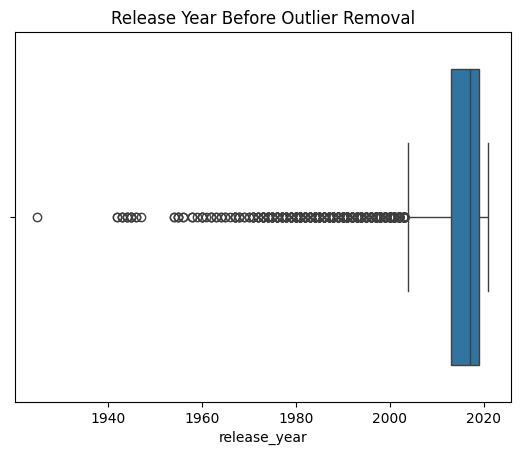

In [91]:
sns.boxplot(x=df["release_year"])

plt.title("Release Year Before Outlier Removal")
plt.show()

In [92]:
Q1 = df["release_year"].quantile(0.25)
Q3 = df["release_year"].quantile(0.75)
IQR= Q3 - Q1

In [93]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [94]:
df_fully_removed = df[(df["release_year"] >= lower_bound) & (df["release_year"] <= upper_bound)]

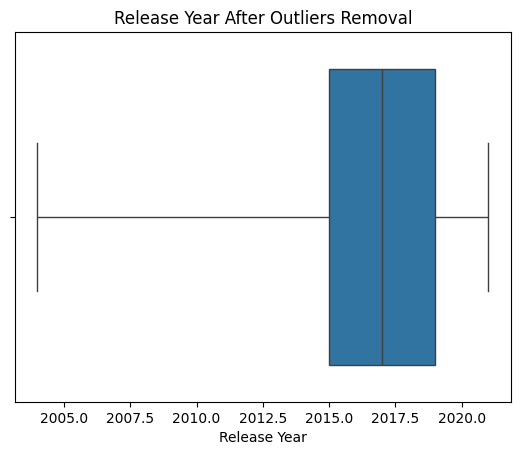

In [95]:
sns.boxplot(x=df_fully_removed["release_year"],whis=np.inf)
plt.title("Release Year After Outliers Removal")
plt.xlabel("Release Year")
plt.show()

**Data Shape After Cleaning**

In [96]:
df.shape

(8807, 12)

**Final Missing Value Check**

In [97]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

**Save Interim Dataset**

In [98]:
df.to_csv(r"C:\Users\fidha\OneDrive\Desktop\eda project\Cleaning preprocessing (2).ipynb", index=False)

## **Final Observations**


Missing values were handled successfully
Duplicate rows were removed
Text standardization was performed to strip trailing whitespaces and convert categorical columns to consistent casing.
Logical inconsistencies and timeline anomalies were addressed to ensure realistic date records.
Datatypes were corrected
Outliers in chronological distribution (release_year) were detected and completely isolated using custom boxplot bounds to ensure zero recalculation noise.
Dataset is now cleaner, structurally consistent, and fully optimized for Exploratory Data Analysis (EDA).